# evaluate GPU utilisation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
from cmath import phase

from pyparsing import col


def load_gpu_logs(file_dict):
    """
    file_dict example:
      {
        "method_A": "methodA.csv",
        "method_B": "methodB.csv"
      }
    Returns: combined dataframe with column 'method'
    """
    dfs = []
    for method, path in file_dict.items():
        df = pd.read_csv(path)
        df["method"] = method
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)
  
def classify(util, idle_thresh=10, active_thresh=60):
    if util < idle_thresh:
        return "idle"
    elif util < active_thresh:
        return "moderate"
    else:
        return "active"
          
def classify_util(df, column, idle_thresh=10, active_thresh=60):
  """
  Returns percent of time GPU spent idle / moderate / active per method
  """

  df["util_state"] = df[column].apply(classify, args=(idle_thresh, active_thresh))
  summary = df.groupby(['method', 'util_state']).size().rename("count").groupby(level=0).transform(lambda x: round(100 * x / x.sum(), 2)).rename("usage (%)").reset_index()
  return summary

def per_phase_gpu_stats(df):
    """
    Returns avg GPU & memory utilization per phase and per method
    """
    stats = (
        df.groupby(["method", "phase"])
          .agg(
              gpu_util_median=("gpu_util_percent", "median"),
              gpu_util_mean=("gpu_util_percent", "mean"),
          )
          .reset_index()
    )
    stats = stats.round(2)
    return stats

def per_phase_mem_stats(df):
    """
    Returns avg GPU & memory utilization per phase and per method
    """
    stats = (
        df.groupby(["method", "phase"])
          .agg(
              mem_util_median=("mem_util_percent", "median"),
              mem_util_mean=("mem_util_percent", "mean"),
          )
          .reset_index()
    )    
    stats = stats.round(2)
    return stats

def per_runtime_stats(df, recording_interval_sec=0.1):
    """
    Returns GPU time spent per phase and per method
    """
    stats = (
        df.groupby(["method", "phase"])
          .agg(
              freq=("time", "size"),
          )
          .reset_index()
    )
    stats["runtime (s)"] = stats["freq"] * recording_interval_sec
    stats = stats.drop(columns=["freq"])
    total_runtime = stats.groupby("method")["runtime (s)"].transform("sum")
    stats["runtime (%)"] = 100 * stats["runtime (s)"] / total_runtime
    stats = stats.round(2)
    return stats

def agg_per_step(df):
    """
    Returns avg GPU & memory utilization per phase and per method
    """
    df_aggr = (
        df.groupby(["method", "phase", "step"])
          .agg(
              gpu_util_median=("gpu_util_percent", "median"),
              gpu_util_mean=("gpu_util_percent", "mean"),
              mem_util_median=("mem_util_percent", "median"),
              mem_util_mean=("mem_util_percent", "mean"),
          )
          .reset_index()
    )    
    df_aggr = df_aggr.round(2)
    return df_aggr


def plot_gpu_util_overlay(df, val_col):
    """
    Overlays GPU utilization vs step curves per method
    """
    plt.figure(figsize=(10,5))

    for method, d in df.groupby("method"):
        d_sorted = d.sort_values("step")
        plt.plot(d_sorted["step"], d_sorted[val_col], alpha=0.6, label=method)

    plt.xlabel("Step")
    plt.ylabel("GPU Utilization (%)")
    plt.title("GPU Utilization vs Training Step")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_smoothed_util(df, val_col, window=20, device="GPU", calculation='mean'):
    """
    Rolling mean smoothing per method
    """
    plt.figure(figsize=(10,5))

    for method, d in df.groupby("method"):
        d_sorted = d.sort_values("step")
        smooth = d_sorted[val_col].rolling(window=window).mean()
        plt.plot(d_sorted["step"], smooth, label=f"{method} (smoothed)")

    plt.xlabel("Step")
    plt.ylabel(f"Smoothed {device} Utilization (%)")
    plt.title(f"Smoothed {calculation} {device} Utilization (window={window})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_smoothed_util_per_phase(df, method, val_col, oppacity=0.2, window=20, device="GPU", calculation='mean'):
    """
    Rolling mean smoothing per method and phase
    """
    plt.figure(figsize=(10,5))
    PHASE_COLORS = {
    "init": "#2c22c5",             # light gray   
    "train": "#696993",            # light blue
    "train_idle": "#baaf90",       # light orange
    "validation": "#AC7D82",       # light green
    "validation_idle": "#ABBCC4",  # light pink
}
    
    df = df.where(df["method"]==method).dropna()
    d_sorted = df.sort_values("step")
    smooth = d_sorted[val_col].rolling(window=window).mean()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(d_sorted["step"], smooth, label=f"{method}", linewidth=3, color="black")
    # fill background per phase
    for row in df.itertuples(index=False):
        ax.axvspan(row.step, row.step + 1, alpha=oppacity, color=PHASE_COLORS[row.phase])
    ax.set_xticks(range(0, int(df['step'].max()), 10))
    ax.set_xlabel("Step")
    ax.set_ylabel(f"Smoothed {device} Utilization (%)")
    ax.set_title(f"Smoothed {calculation} {device} Utilization per Phase (window={window})")
    # --- legends ---
    phase_handles = [Patch(facecolor=color, edgecolor="none", label=phase) for phase, color in PHASE_COLORS.items()]
    line_handles, line_labels = ax.get_legend_handles_labels()
    ax.legend(handles=line_handles + phase_handles)
    plt.tight_layout()
    plt.show()



In [3]:
file_dict = {
    "on-the-fly": "./GPUlog_on_OnTheFly.csv",
    "precomputed": "./GPUlog_on_PreComputed.csv"
}

df = load_gpu_logs(file_dict)

In [4]:
classify_util(df, column="gpu_util_percent", idle_thresh=5, active_thresh=60)

,method,util_state,usage (%)
0,on-the-fly,active,43.05
1,on-the-fly,idle,42.86
2,on-the-fly,moderate,14.09
3,precomputed,active,85.56
4,precomputed,idle,4.10
5,precomputed,moderate,10.34


In [5]:
classify_util(df, column="mem_util_percent", idle_thresh=5, active_thresh=60)

,method,util_state,usage (%)
0,on-the-fly,active,10.31
1,on-the-fly,idle,44.98
2,on-the-fly,moderate,44.71
3,precomputed,active,21.35
4,precomputed,idle,4.78
5,precomputed,moderate,73.87


In [6]:
df_aggr = per_phase_gpu_stats(df)
df_aggr

,method,phase,gpu_util_median,gpu_util_mean
0,on-the-fly,init,0.0,0.53
1,on-the-fly,train,85.0,68.77
2,on-the-fly,train_idle,0.0,11.57
3,on-the-fly,validation,25.0,46.76
4,on-the-fly,validation_idle,0.0,1.08
5,precomputed,init,0.0,0.53
6,precomputed,train,95.0,82.91
7,precomputed,train_idle,92.0,90.90
8,precomputed,validation,100.0,95.65
9,precomputed,validation_idle,0.0,7.83


In [7]:
per_phase_mem_stats(df)

,method,phase,mem_util_median,mem_util_mean
0,on-the-fly,init,0.0,0.03
1,on-the-fly,train,27.0,32.51
2,on-the-fly,train_idle,0.0,7.63
3,on-the-fly,validation,12.0,19.50
4,on-the-fly,validation_idle,0.0,0.65
5,precomputed,init,0.0,0.02
6,precomputed,train,28.0,38.64
7,precomputed,train_idle,77.0,75.24
8,precomputed,validation,27.0,39.97
9,precomputed,validation_idle,0.0,4.19


In [8]:
df

,time,gpu-id,gpu_util_percent,mem_util_percent,mem_util_MB,mem_free_MB,mem_total_MB,phase,epoch,step,method,util_state
0,1.768162e+09,0,9,0,1116.4375,14243.5625,15360.0,init,-1,-1,on-the-fly,idle
1,1.768162e+09,0,16,1,1132.4375,14227.5625,15360.0,init,-1,-1,on-the-fly,idle
2,1.768162e+09,0,16,1,1132.4375,14227.5625,15360.0,init,-1,-1,on-the-fly,idle
3,1.768162e+09,0,0,0,1132.4375,14227.5625,15360.0,init,-1,-1,on-the-fly,idle
4,1.768162e+09,0,0,0,1132.4375,14227.5625,15360.0,init,-1,-1,on-the-fly,idle
...,...,...,...,...,...,...,...,...,...,...,...,...
16269,1.768164e+09,0,8,0,10856.4375,4503.5625,15360.0,validation_idle,2,294,precomputed,idle
16270,1.768164e+09,0,8,0,10856.4375,4503.5625,15360.0,validation_idle,2,294,precomputed,idle
16271,1.768164e+09,0,8,0,10856.4375,4503.5625,15360.0,validation_idle,2,294,precomputed,idle
16272,1.768164e+09,0,8,0,7428.4375,7931.5625,15360.0,validation_idle,2,294,precomputed,idle


In [9]:
per_runtime_stats(df, recording_interval_sec=0.1)

,method,phase,runtime (s),runtime (%)
0,on-the-fly,init,7.8,0.79
1,on-the-fly,train,318.1,32.41
2,on-the-fly,train_idle,135.2,13.77
3,on-the-fly,validation,433.2,44.14
4,on-the-fly,validation_idle,87.2,8.88
5,precomputed,init,8.9,1.38
6,precomputed,train,355.9,55.10
7,precomputed,train_idle,4.2,0.65
8,precomputed,validation,265.1,41.04
9,precomputed,validation_idle,11.8,1.83


In [10]:
df_aggr = agg_per_step(df)
df_aggr


,method,phase,step,gpu_util_median,gpu_util_mean,mem_util_median,mem_util_mean
0,on-the-fly,init,-1,0.0,0.53,0.0,0.03
1,on-the-fly,train,0,57.0,52.83,23.5,23.33
2,on-the-fly,train,1,22.0,22.86,11.0,12.57
3,on-the-fly,train,2,96.0,81.60,31.0,40.90
4,on-the-fly,train,3,82.5,77.80,33.0,42.40
...,...,...,...,...,...,...,...
741,precomputed,validation,294,100.0,96.77,27.0,40.42
742,precomputed,validation_idle,0,0.0,8.43,0.0,8.09
743,precomputed,validation_idle,98,0.0,3.88,0.0,1.52
744,precomputed,validation_idle,196,0.0,9.41,0.0,5.94


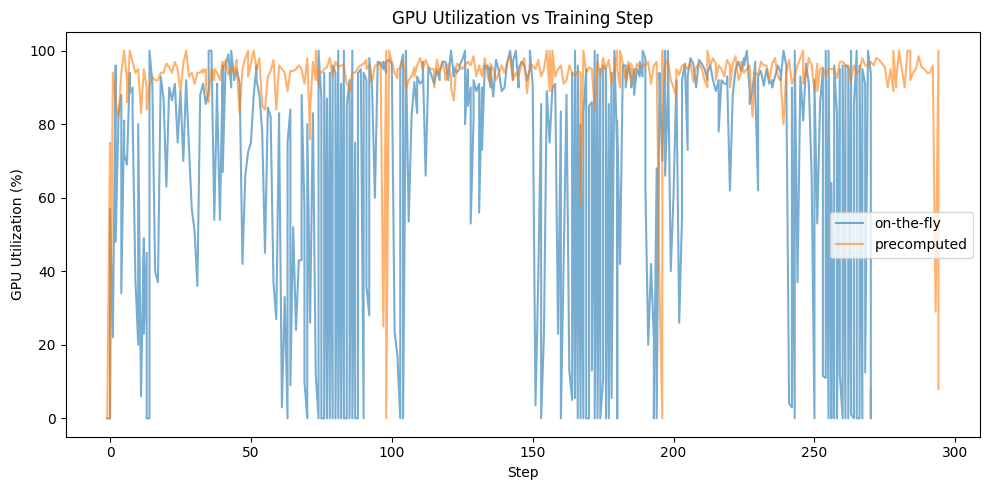

In [11]:
plot_gpu_util_overlay(df_aggr, val_col="gpu_util_median")

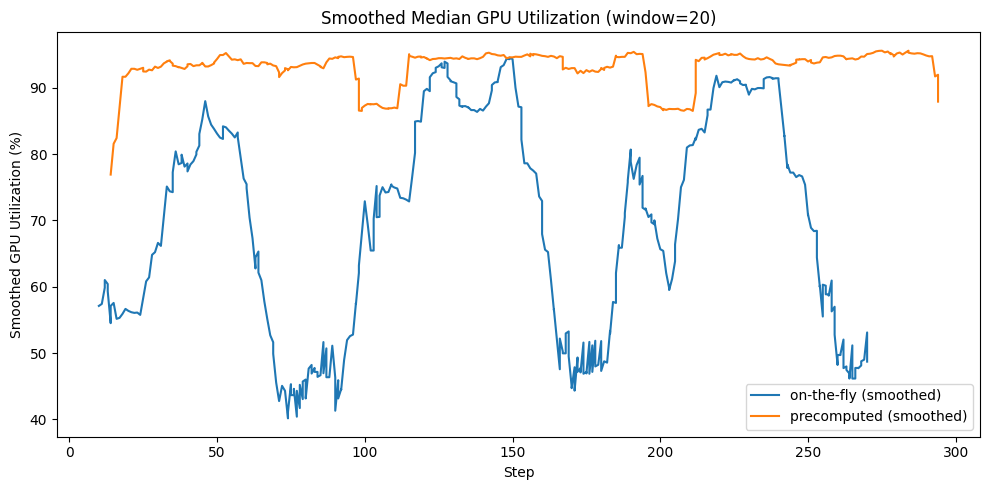

In [12]:
plot_smoothed_util(df_aggr, val_col="gpu_util_median", window=20, device="GPU", calculation='Median')

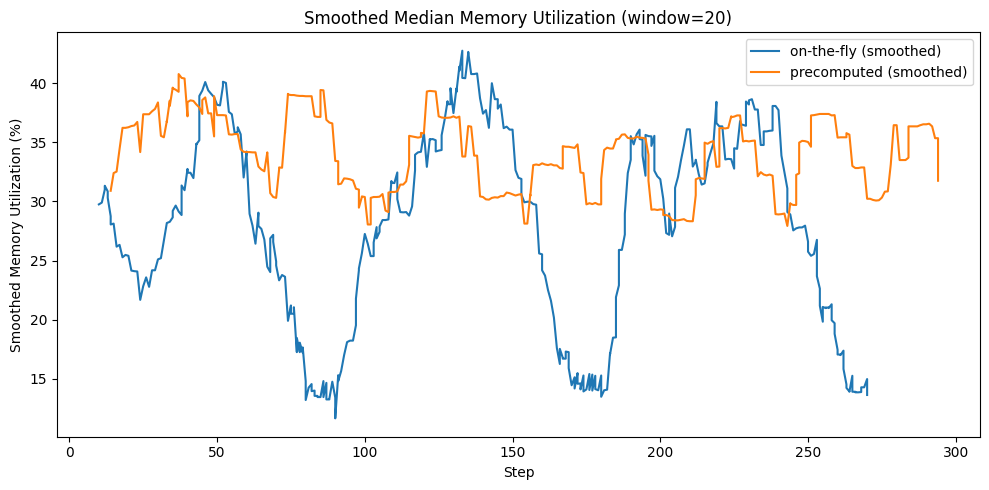

In [13]:
plot_smoothed_util(df_aggr, val_col="mem_util_median", window=20, device="Memory", calculation='Median')

<Figure size 1000x500 with 0 Axes>

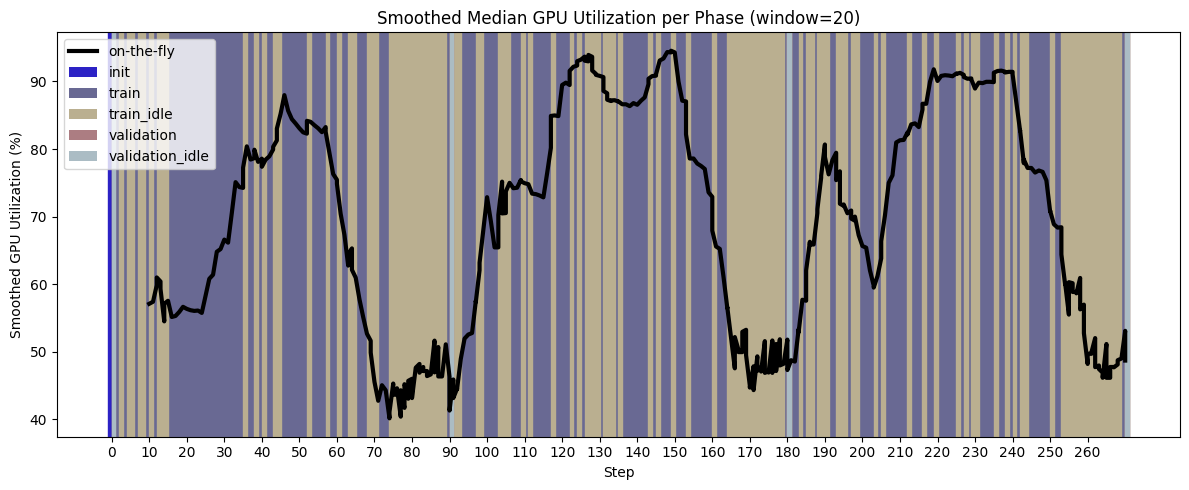

In [14]:
plot_smoothed_util_per_phase(df_aggr, method='on-the-fly', oppacity=1.0, val_col='gpu_util_median', window=20, device="GPU", calculation='Median')

<Figure size 1000x500 with 0 Axes>

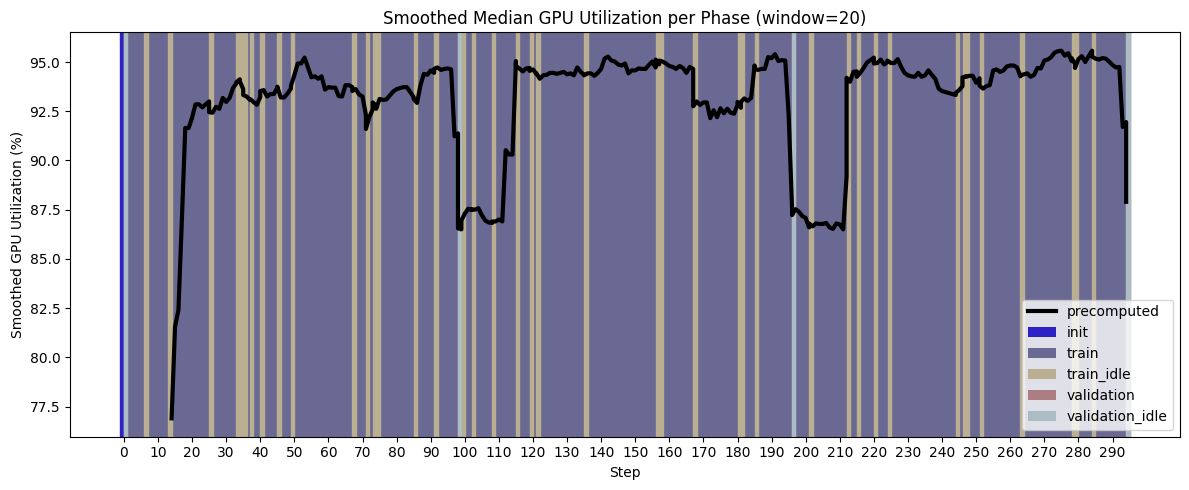

In [15]:
plot_smoothed_util_per_phase(df_aggr, method='precomputed', oppacity=1, val_col='gpu_util_median', window=20, calculation='Median')